# Trend Prediciton

## 1. Data Validation

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime

In [2]:
TICKERS = "GOOGL"
yearlb = 5
START = (pd.Timestamp.today() - pd.DateOffset(years=yearlb)).strftime("%Y-%m-%d")
END = pd.Timestamp.today().strftime("%Y-%m-%d")

In [3]:
stock = yf.download(tickers=TICKERS, start=START, end=END, progress=False, multi_level_index= False)

/tmp/ipykernel_253427/1212267724.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(tickers=TICKERS, start=START, end=END, progress=False, multi_level_index= False)


In [4]:
stock

,Close,High,Low,Open,Volume
Date,,,,,
2020-11-06,87.383804,87.819300,86.239195,86.967176,28622000
2020-11-09,87.467720,90.222220,87.275549,89.183888,53440000
2020-11-10,86.290848,87.366430,85.218244,85.896071,43022000
2020-11-11,86.763100,87.541226,86.556024,86.821194,31838000
2020-11-12,86.544106,87.644518,86.303266,86.503386,26474000
...,...,...,...,...,...
2025-10-30,281.480011,291.589996,280.059998,291.589996,74876000
2025-10-31,281.190002,286.000000,277.029999,283.209991,39267900
2025-11-03,283.720001,285.529999,279.799988,282.179993,29786000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
plt.figure(figsize=(14, 7))

<Figure size 1400x700 with 0 Axes>

<Figure size 1400x700 with 0 Axes>

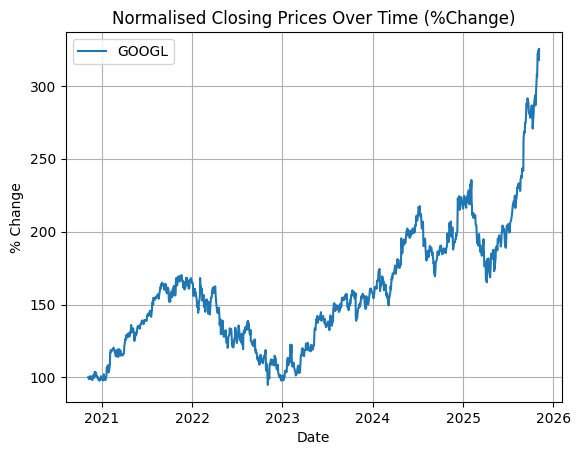

In [19]:
stock_normalized = stock['Close'] / stock['Close'].iloc[0] * 100

plt.plot(stock_normalized, label=TICKERS)

plt.title('Normalised Closing Prices Over Time (%Change)')
plt.xlabel('Date')
plt.ylabel('% Change')
plt.legend()
plt.grid(True)
plt.savefig(f"norm_{TICKERS}.png")
plt.show()

## 2. Computing Financial Metrics

- **Log Returns (`logret`)**: ค่าลอการิทึมธรรมชาติของการเปลี่ยนแปลงราคาประจำวัน
- **Percentage Returns (`ret`)**: การเปลี่ยนแปลงราคาประจำวันเป็นเปอร์เซ็นต์
- **Realized Volatility (`realized_vol_annual`, `roll30_vol`, `roll60_vol`, `roll180_vol`)**: การวัดความผันผวนของราคาในอดีตในช่วงเวลา rolling window ที่แตกต่างกัน โดยคิดเป็นรายปี
- **Beta (`beta60`)**: การวัดความผันผวนของหุ้นเทียบกับ benchmark ในช่วง rolling window 60 วัน
- **Skewness (`skew60`)**: การวัดความไม่สมมาตรของการกระจายผลตอบแทนในช่วง rolling window 60 วัน
- **Kurtosis (`kurt60`)**: การวัด "tailedness" ของการกระจายผลตอบแทนเทียบกับการกระจายปกติในช่วง rolling window 60 วัน
- **Average True Range (`ATR7`)**: การวัดความผันผวนของตลาด คำนวณในช่วง rolling window 7 วัน
- **Big Move (`big_move`)**: ตัวบ่งชี้ไบนารี (0 หรือ 1) หากผลตอบแทนรายวันแบบสัมบูรณ์มากกว่า 2%
- **Monthly and Quarterly Returns (`ret_1m`, `ret_3m`)**: การเปลี่ยนแปลงราคาเป็นเปอร์เซ็นต์ในช่วงประมาณ 1 เดือน (21 วันทำการ) และ 3 เดือน (63 วันทำการ)

In [8]:
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestRegressor
import json

In [9]:
# ---------- Compute factor metrics ----------
def compute_factors(df):
    df = df.copy()
    df['logret'] = np.log(df['Close']).diff()
    df['ret'] = df['Close'].pct_change()
    df['realized_vol_annual'] = df['logret'].rolling(window=252).std() * np.sqrt(252)
    df['roll30_vol'] = df['logret'].rolling(30).std() * np.sqrt(252)
    df['roll60_vol'] = df['logret'].rolling(60).std() * np.sqrt(252)
    df['roll180_vol'] = df['logret'].rolling(180).std() * np.sqrt(252)
    # beta: need benchmark logret
    df['skew60'] = df['logret'].rolling(60).apply(lambda x: skew(x.dropna()), raw=False)
    df['kurt60'] = df['logret'].rolling(60).apply(lambda x: kurtosis(x.dropna(), fisher=False), raw=False)

    # ATR
    hl = df['High'] - df['Low']
    hc = (df['High'] - df['Close'].shift()).abs()
    lc = (df['Low'] - df['Close'].shift()).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    df['ATR5'] = tr.rolling(5).mean()
    df['ROC5'] = df['Close'].pct_change(periods=5) * 100
    df['ROC10'] = df['Close'].pct_change(periods=10) * 100

    # % of days with > 2% move (abs daily return)
    df['big_move'] = (df['ret'].abs() > 0.02).astype(int)
    df['spread'] = df['High'] - df['Low']
    
    return df

In [10]:
df = compute_factors(stock)

In [11]:
df.tail()

,Close,High,Low,Open,Volume,logret,ret,realized_vol_annual,roll30_vol,roll60_vol,roll180_vol,skew60,kurt60,ATR5,ROC5,ROC10,big_move,spread
Date,,,,,,,,,,,,,,,,,,
2025-10-30,281.480011,291.589996,280.059998,291.589996,74876000,0.024855,0.025167,0.326422,0.253933,0.283713,0.320897,1.737141,8.615973,9.587997,11.221752,11.938282,1,11.529999
2025-10-31,281.190002,286.000000,277.029999,283.209991,39267900,-0.001031,-0.001030,0.326065,0.253413,0.283976,0.320640,1.740507,8.605456,9.662000,8.183283,11.010659,0,8.970001
2025-11-03,283.720001,285.529999,279.799988,282.179993,29786000,0.008957,0.008997,0.325114,0.251336,0.281386,0.320620,1.813784,9.012058,8.764001,5.366366,10.590534,0,5.730011
2025-11-04,277.540009,281.269989,276.260010,276.750000,30078400,-0.022023,-0.021782,0.325298,0.261599,0.286667,0.321691,1.710436,8.586529,9.409998,3.764911,10.812106,1,5.009979
2025-11-05,284.309998,286.329987,277.339996,278.894989,30163316,0.024100,0.024393,0.326051,0.260223,0.288961,0.322652,1.653211,8.258829,9.633997,3.547361,12.960386,1,8.989990


## 3. Machine Learning Trend Prediction

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas_ta as ta

In [13]:
feature_columns0 = ['Open', 'High', 'Low', 'Close', 'Volume', 'logret', 'big_move', 'spread']

istock = df[feature_columns0]

# feature engineering with indicators from technical analysis
istock['RSI14'] = ta.rsi(istock['Close'], length=14)
istock['EMA5'] = ta.wma(istock['Close'], length=5)
istock['EMA10'] = ta.wma(istock['Close'], length=10)
istock['ATR'] = ta.atr(high=istock['High'], low=istock['Low'], close=istock['Close'], mamode="rma")

istock['MA_diff'] = istock['EMA5'] - istock['EMA10']
istock['price_diff'] = istock['Close'] - istock['EMA5']

imacd = ta.macd(istock['Close'], fast=12, slow=26, signal=9)
istock['macd'] = imacd['MACD_12_26_9']
istock['macd_signal'] = imacd['MACDs_12_26_9']
istock['macd_hist'] = imacd['MACDh_12_26_9']

istock['MOM5'] = ta.mom(istock['Close'], length=5)
istock['mom_type'] = np.where((istock.MOM5 >= 0), 1, -1)
istock['strong_pos'] = np.where((istock.MOM5 >= 0) & (istock.MOM5 > istock.MOM5.shift(1)), 1, 0)
istock['strong_neg'] = np.where((istock.MOM5 < 0) & (istock.MOM5 < istock.MOM5.shift(1)), 1, 0)

istock.tail()

,Open,High,Low,Close,Volume,logret,big_move,spread,RSI14,EMA5,...,ATR,MA_diff,price_diff,macd,macd_signal,macd_hist,MOM5,mom_type,strong_pos,strong_neg
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-30,291.589996,291.589996,280.059998,281.480011,74876000,0.024855,1,11.529999,77.696964,273.770005,...,7.268095,7.223820,7.710006,8.784668,6.360458,2.424210,28.400009,1,1,0
2025-10-31,283.209991,286.000000,277.029999,281.190002,39267900,-0.001031,0,8.970001,77.258153,277.319338,...,7.389659,7.243880,3.870664,9.623695,7.013105,2.610590,21.269989,1,0,0
2025-11-03,282.179993,285.529999,279.799988,283.720001,29786000,0.008957,0,5.730011,78.404037,280.294004,...,7.271113,6.736364,3.425997,10.373204,7.685125,2.688079,14.450012,1,0,0
2025-11-04,276.750000,281.269989,276.260010,277.540009,30078400,-0.022023,1,5.009979,69.228111,280.245339,...,7.284604,4.823153,-2.705330,10.349222,8.217944,2.131278,10.070007,1,0,0
2025-11-05,278.894989,286.329987,277.339996,284.309998,30163316,0.024100,1,8.989990,72.961315,281.782003,...,7.406418,3.756727,2.527995,10.752549,8.724865,2.027684,9.739990,1,0,0


In [14]:
# create label for the current price if it is going up or not
istock['future'] = (istock['Close'].shift(-1) > istock['Close']).astype(int)

In [15]:
# feature selection (X)
feature_columns = [
    'logret', 'mom_type', 'strong_pos', 'strong_neg', 'price_diff', 'Close', 'MOM5', 'macd_signal', 'RSI14', 'ATR'
]
X0 = istock[feature_columns]

# labels (y)
y0 = istock['future']

# drop rows with nan and align X and y
combined_df = pd.concat([X0, y0], axis=1).dropna()
X = combined_df[feature_columns]
y = combined_df['future']

combined_df.tail(10)

,logret,mom_type,strong_pos,strong_neg,price_diff,Close,MOM5,macd_signal,RSI14,ATR,future
Date,,,,,,,,,,,
2025-10-23,0.005507,1,1,0,0.417334,253.080002,1.619995,4.695822,60.849995,6.125328,1
2025-10-24,0.026668,1,1,0,4.956008,259.920013,6.620010,4.738692,66.986005,6.302089,1
2025-10-27,0.035341,1,1,0,9.329321,269.269989,12.720001,4.984247,73.175141,6.581940,0
2025-10-28,-0.006707,1,1,0,4.000667,267.470001,17.009995,5.303892,70.437481,6.413945,1
2025-10-29,0.026199,1,1,0,6.339338,274.570007,22.880005,5.754405,74.491411,6.517949,1
2025-10-30,0.024855,1,1,0,7.710006,281.480011,28.400009,6.360458,77.696964,7.268095,0
2025-10-31,-0.001031,1,0,0,3.870664,281.190002,21.269989,7.013105,77.258153,7.389659,1
2025-11-03,0.008957,1,0,0,3.425997,283.720001,14.450012,7.685125,78.404037,7.271113,0
2025-11-04,-0.022023,1,0,0,-2.705330,277.540009,10.070007,8.217944,69.228111,7.284604,1


Trend Prediction

In [16]:
# prepare train and test size
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (977, 10)
X_test Shape: (245, 10)
y_train Shape: (977,)
y_test Shape: (245,)


In [17]:
# SVC model training
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

cls = svm_model.fit(X_train, y_train)
train_confusion = confusion_matrix(y_train, cls.predict(X_train))
test_confustoin = confusion_matrix(y_test, cls.predict(X_test))

train_report = classification_report(y_train, cls.predict(X_train))
test_report = classification_report(y_test, cls.predict(X_test))

print(f"Train Dataset Confusion Matrix:\n{train_confusion}")
print(f"Train Dataset Report:\n{train_report}")
print("----------------------------------")
print(f"Test Dataset Confusion Matrix:\n{test_confustoin}")
print(f"Test Dataset Report:\n{test_report}")

Train Dataset Confusion Matrix:
[[  0 449]
 [  0 528]]
Train Dataset Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       449
           1       0.54      1.00      0.70       528

    accuracy                           0.54       977
   macro avg       0.27      0.50      0.35       977
weighted avg       0.29      0.54      0.38       977

----------------------------------
Test Dataset Confusion Matrix:
[[  0 114]
 [  0 131]]
Test Dataset Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       114
           1       0.53      1.00      0.70       131

    accuracy                           0.53       245
   macro avg       0.27      0.50      0.35       245
weighted avg       0.29      0.53      0.37       245



/home/akito1961/Documents/Quant Python/trend_prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/akito1961/Documents/Quant Python/trend_prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/akito1961/Documents/Quant Python/trend_prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

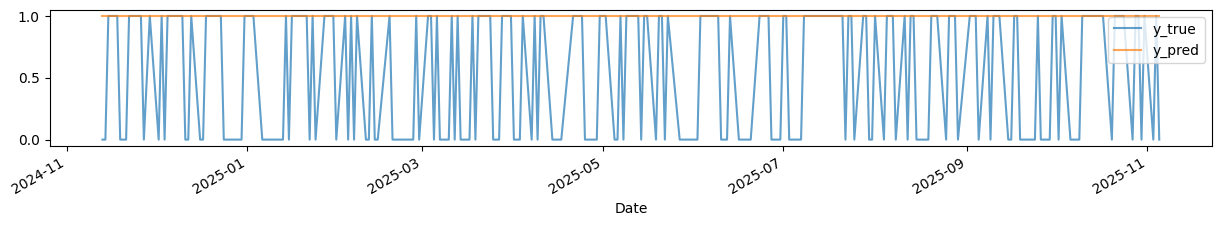

In [21]:
y_pred = cls.predict(X_test)
_ = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred}).plot(figsize=(15, 2), alpha=.7)